In [9]:
import numpy as np
import pandas as pd
#import umap
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
from anndata import AnnData
from muon import prot as pt
from sklearn import preprocessing

Here I load the spatial data, which consists of the protein intensity per cell, and the geometry location of the cell. I use the cell type annotation from AnnoSpat

read intensities ( protein level per cell)

In [2]:
intensities = pd.read_csv('./processed_files/all_data_intensities.csv',index_col=0)
intensities['ROI'] = pd.to_numeric(intensities.ROI.str[-3:])#make ROI numeric
columns_to_extract = intensities.columns.difference(['ROI', 'source_file'])
intensities_protein = intensities[columns_to_extract]#contains only numeric values (intensities)

The variable`regions` contains the spatial properties of the cells. Cell geometry and location is obtained from ilastik and CellProfiler

In [3]:
regions = pd.read_csv('./processed_files/all_data_regions.csv',index_col=0)
regions.head()

,area,centroid-0,centroid-1,major_axis_length,minor_axis_length,eccentricity,source_file
0,16,1.500000,1.500000,4.472136,4.472136,0.000000,Leap002_003
1,26,1.730769,6.346154,6.458965,5.156497,0.602197,Leap002_003
2,73,2.082192,15.698630,16.540737,5.932868,0.933460,Leap002_003
3,62,1.838710,35.532258,14.916095,5.917155,0.917950,Leap002_003
4,23,0.956522,45.608696,9.966303,3.081719,0.950993,Leap002_003


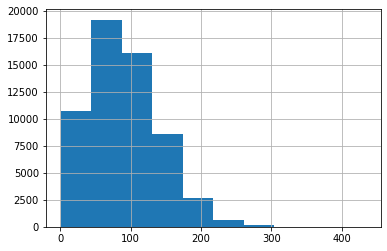

In [23]:
regions.area.hist()

#pt.pp.clr(adata)

In [7]:
#adata
pt.pp.clr(adata)

cell type annotation comes from AnnoSpat

In [11]:
labels = pd.read_csv('output/trte_labels_ELM_IMC_T1D_AnnoSpat.csv')
num_labels = pd.read_csv('output/trte_labels_numericLabels_ELM_IMC_T1D_AnnoSpat.csv')
mapper = dict(zip(num_labels.label,labels.label))#convert numeric labels to cell types


Using the analysis of [squidpy](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_read_spatial.html) 

In [14]:
adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})

<ipython-input-14-20ab53a2c261>:1: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


[]

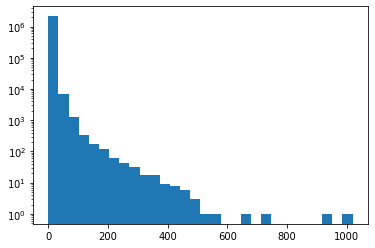

In [20]:
sc.pp.log1p?

In [21]:

#“centered log ratio"
adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
adata.obs['AnnoSpat'] = num_labels.label.values.astype(str)
#“centered log ratio"
sc.pp.log1p(adata)

#sc.pp.normalize_total(adata)# it uses the l1 norm, we like the l2 instead
adata.X = preprocessing.normalize(adata.X, norm='l2')
#sc.pp.pca(adata,n_comps=25)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)


<ipython-input-21-66092b8cd3ea>:2: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [25]:
sc.pp.neighbors?
adata

AnnData object with n_obs × n_vars = 58031 × 37
    obs: 'AnnoSpat', 'leiden'
    uns: 'log1p', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'spatial', 'X_umap'
    obsp: 'distances', 'connectivities'

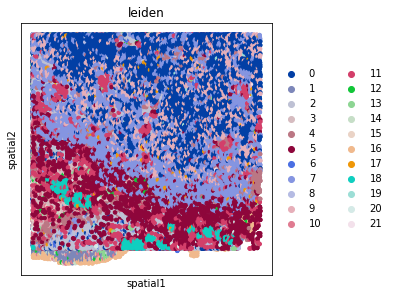

In [22]:
sq.pl.spatial_scatter(adata, shape=None, color="leiden", size=50)


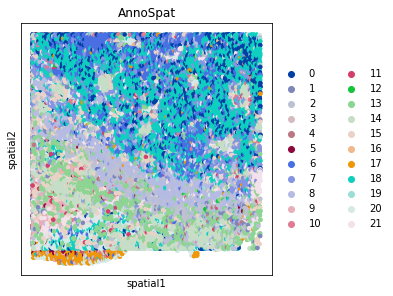

In [7]:
sq.pl.spatial_scatter(adata, shape=None, color="AnnoSpat", size=50)


mapping from cell type label to name

In [8]:
pd.DataFrame.from_dict(mapper,orient='index',columns=['Cell_type']).sort_index()#for AnnoSpat, this is the mapping from cell type label to name

,Cell_type
0,Cancer
1,CD163p_Mac [M2]
2,CD163n_Mac [M1]
3,Naive CD4 T cells
4,Memory T cells
5,Regulatory T cells
6,Naive CD8 T cells
7,Memory CD8 T cells
8,Naive B cells
9,Memory B cells


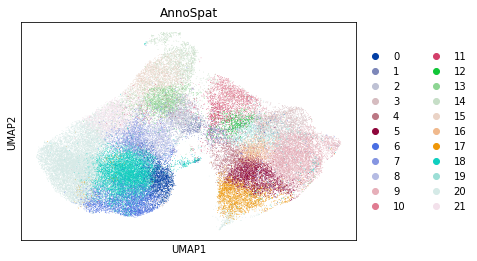

In [53]:
sc.pl.umap(adata,color='AnnoSpat')

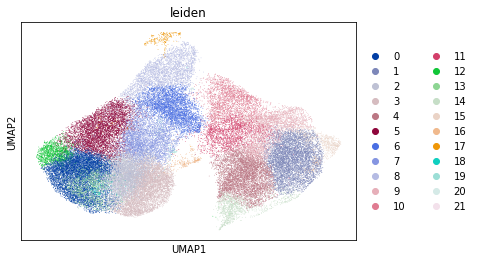

In [10]:
sc.pl.umap(adata,color='leiden')

  0%|          | 0/1000 [00:00<?, ?/s]

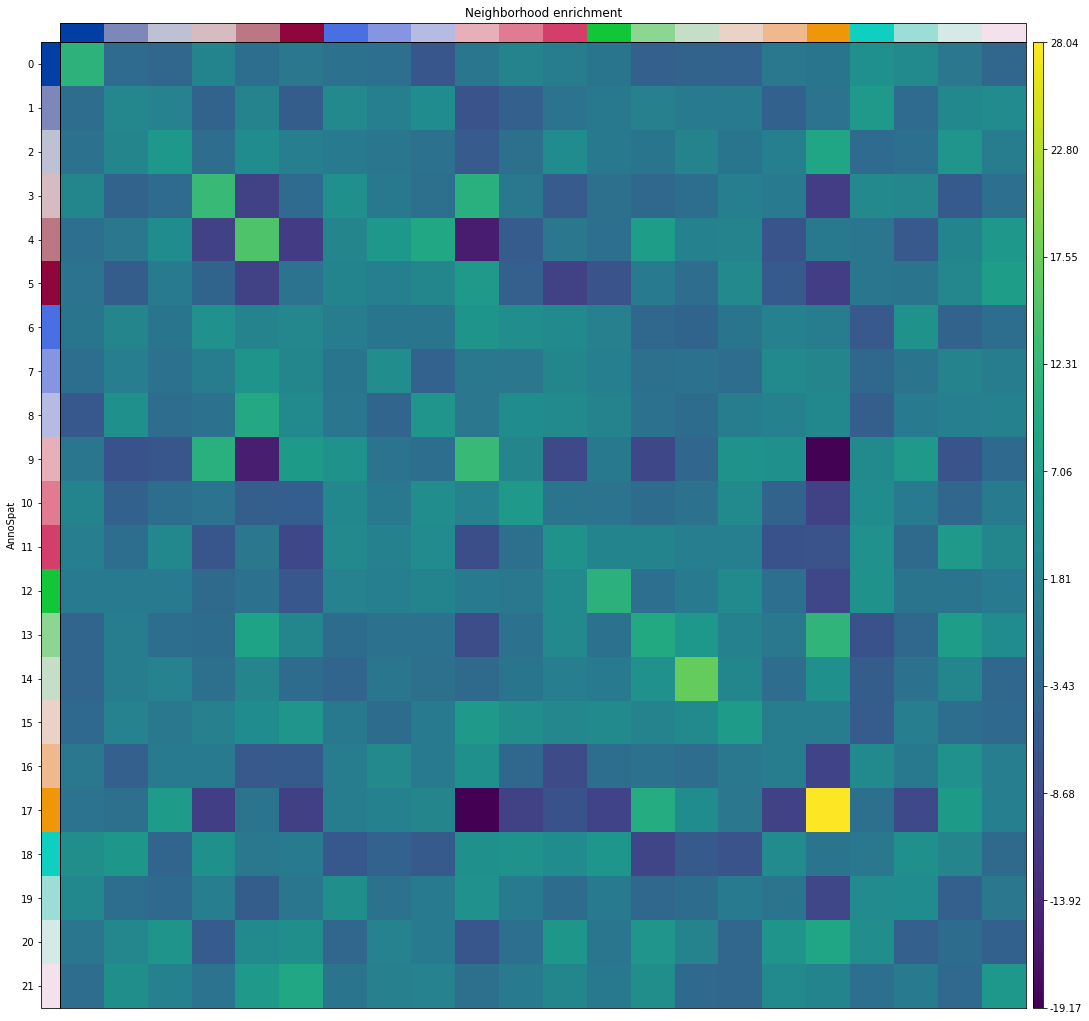

In [18]:
sq.gr.spatial_neighbors(adata)
sq.gr.nhood_enrichment(adata, cluster_key='AnnoSpat')
sq.pl.nhood_enrichment(adata, cluster_key='AnnoSpat')

In [15]:
intensities_protein

,Alpha-SMA,B7-H4,Beta-Catenin,CD107a,CD11b,CD14,CD16,CD163,CD20,CD27,...,HLA-DR-DQ-DP,Ki-67,PD-1,PD-L1,PD-L2,Pan-keratin,Tbet,VEGF,Vimentin,p53
0,1.407416,2.122283,0.132157,1.062819,1.428627,0.868680,0.177013,0.062500,0.000000,0.144994,...,0.355577,0.073719,0.418730,0.176200,0.467670,1.165243,0.639988,1.236545,0.506011,0.764117
1,1.002858,1.578596,0.079751,0.992185,0.845461,0.305964,0.085043,0.000000,0.078117,0.308680,...,0.220604,0.375084,0.153846,0.370850,0.413358,1.743893,0.519610,1.434332,0.631692,0.076923
2,0.676052,1.296754,0.206407,1.623834,1.613524,1.066378,0.408479,0.186198,0.084808,0.590248,...,0.252249,1.822916,0.287498,0.280647,0.505237,1.345208,0.475544,1.824287,0.496595,0.561728
3,0.819292,1.593268,0.305057,1.850551,1.586432,1.175608,0.375068,0.177496,0.067077,0.549276,...,0.341070,1.686514,0.512750,0.531933,0.451247,3.742146,0.543862,2.460904,0.462176,0.358976
4,0.382099,1.381853,0.698653,2.105125,2.430705,1.725331,0.697254,0.130107,0.000000,0.504643,...,0.335712,0.274934,0.396853,0.228462,0.218492,1.264105,0.676068,2.639438,0.308627,0.289157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58026,2.858710,0.548561,0.125000,0.597034,0.438662,0.594400,0.125000,0.282787,0.000000,0.233998,...,0.211547,0.000000,0.089415,0.244458,0.324560,0.000000,0.167244,0.349684,17.166137,0.610904
58027,3.634336,0.797229,0.126296,0.734352,0.963141,0.768178,0.862238,0.125000,0.000000,0.140504,...,4.953387,0.000000,0.337340,0.125700,0.347945,0.000000,0.125000,0.651406,24.829326,0.227736
58028,1.111256,0.863939,0.097778,1.301125,0.787042,0.949086,0.601291,0.414665,0.071429,0.000000,...,1.523970,0.071429,0.231111,0.262222,0.151906,0.178636,0.090889,1.524077,86.095577,0.225826
58029,0.689112,0.903644,0.268007,0.659457,1.194929,0.939658,0.081695,0.185751,0.028438,0.380768,...,0.362913,0.048820,0.103548,0.164473,0.253176,0.178665,0.162893,1.202006,17.769594,0.128664
